<a href="https://colab.research.google.com/github/mylethidiem/zero-to-hero/blob/main/data_ai_core/deep_learning/cnn/cifar10_tutorial_modified2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dùng GPU, Adam, thiết kế CNN với 10 conv (2 lớp có stride = 2), 3 pooling 2x2

In [1]:
%matplotlib inline


Training a Classifier
=====================

This is it. You have seen how to define neural networks, compute loss and make
updates to the weights of the network.

Now you might be thinking,

What about data?
----------------

Generally, when you have to deal with image, text, audio or video data,
you can use standard python packages that load data into a numpy array.
Then you can convert this array into a ``torch.*Tensor``.

-  For images, packages such as Pillow, OpenCV are useful
-  For audio, packages such as scipy and librosa
-  For text, either raw Python or Cython based loading, or NLTK and
   SpaCy are useful

Specifically for vision, we have created a package called
``torchvision``, that has data loaders for common datasets such as
Imagenet, CIFAR10, MNIST, etc. and data transformers for images, viz.,
``torchvision.datasets`` and ``torch.utils.data.DataLoader``.

This provides a huge convenience and avoids writing boilerplate code.

For this tutorial, we will use the CIFAR10 dataset.
It has the classes: ‘airplane’, ‘automobile’, ‘bird’, ‘cat’, ‘deer’,
‘dog’, ‘frog’, ‘horse’, ‘ship’, ‘truck’. The images in CIFAR-10 are of
size 3x32x32, i.e. 3-channel color images of 32x32 pixels in size.

.. figure:: /_static/img/cifar10.png
   :alt: cifar10

   cifar10


Training an image classifier
----------------------------

We will do the following steps in order:

1. Load and normalizing the CIFAR10 training and test datasets using
   ``torchvision``
2. Define a Convolution Neural Network
3. Define a loss function
4. Train the network on the training data
5. Test the network on the test data

1. Loading and normalizing CIFAR10
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Using ``torchvision``, it’s extremely easy to load CIFAR10.



In [2]:
import torch
import torchvision
import torchvision.transforms as transforms

The output of torchvision datasets are PILImage images of range [0, 1].
We transform them to Tensors of normalized range [-1, 1].



In [3]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:04<00:00, 35.0MB/s]


Let us show some of the training images, for fun.



plane  frog   dog   dog


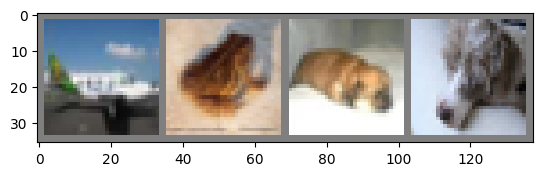

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image

def imshow(img):
    # Bỏ chuẩn hóa (unnormalize) hình ảnh từ dải [-1, 1] về [0, 1] để hiển thị đúng.
    # Quá trình chuẩn hóa là (input - mean) / std. Để đảo ngược, ta làm (img * std) + mean.
    # Với mean=0.5 và std=0.5, công thức trở thành (img * 0.5) + 0.5
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()     # Chuyển đổi tensor PyTorch sang mảng NumPy
    # Chuyển đổi thứ tự chiều từ (Kênh, Chiều cao, Chiều rộng) sang (Chiều cao, Chiều rộng, Kênh)
    # để phù hợp với định dạng hiển thị của matplotlib.
    plt.imshow(np.transpose(npimg, (1, 2, 0)))


# Lấy một số hình ảnh huấn luyện ngẫu nhiên
dataiter = iter(trainloader) # Tạo một iterator từ DataLoader của tập huấn luyện
images, labels = next(dataiter) # Lấy một lô (batch) hình ảnh và nhãn từ iterator

# Hiển thị các hình ảnh
# torchvision.utils.make_grid tạo một hình ảnh lưới duy nhất từ nhiều hình ảnh trong một lô
imshow(torchvision.utils.make_grid(images))
# In ra các nhãn tương ứng của 4 hình ảnh đầu tiên trong lô
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

2. Define a Convolution Neural Network
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Copy the neural network from the Neural Networks section before and modify it to
take 3-channel images (instead of 1-channel images as it was defined).



In [ ]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

3. Define a Loss function and optimizer
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Let's use a Classification Cross-Entropy loss and SGD with momentum.



In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
# optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
optimizer = optim.Adam(net.parameters(), lr=0.001)

4. Train the network
^^^^^^^^^^^^^^^^^^^^

This is when things start to get interesting.
We simply have to loop over our data iterator, and feed the inputs to the
network and optimize.



In [ ]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')

5. Test the network on the test data
^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

We have trained the network for 2 passes over the training dataset.
But we need to check if the network has learnt anything at all.

We will check this by predicting the class label that the neural network
outputs, and checking it against the ground-truth. If the prediction is
correct, we add the sample to the list of correct predictions.

Okay, first step. Let us display an image from the test set to get familiar.



In [ ]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join('%5s' % classes[labels[j]] for j in range(4)))

Okay, now let us see what the neural network thinks these examples above are:



In [ ]:
outputs = net(images)

The outputs are energies for the 10 classes.
Higher the energy for a class, the more the network
thinks that the image is of the particular class.
So, let's get the index of the highest energy:



In [ ]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join('%5s' % classes[predicted[j]]
                              for j in range(4)))

The results seem pretty good.

Let us look at how the network performs on the whole dataset.



In [ ]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

That looks waaay better than chance, which is 10% accuracy (randomly picking
a class out of 10 classes).
Seems like the network learnt something.

Hmmm, what are the classes that performed well, and the classes that did
not perform well:



In [ ]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(4):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1


for i in range(10):
    print('Accuracy of %5s : %2d %%' % (
        classes[i], 100 * class_correct[i] / class_total[i]))

Okay, so what next?

How do we run these neural networks on the GPU?

Training on GPU
----------------
Just like how you transfer a Tensor on to the GPU, you transfer the neural
net onto the GPU.

Let's first define our device as the first visible cuda device if we have
CUDA available:



In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Assume that we are on a CUDA machine, then this should print a CUDA device:

print(device)

The rest of this section assumes that `device` is a CUDA device.

Then these methods will recursively go over all modules and convert their
parameters and buffers to CUDA tensors:

.. code:: python

    net.to(device)


Remember that you will have to send the inputs and targets at every step
to the GPU too:

.. code:: python

        inputs, labels = inputs.to(device), labels.to(device)

Why dont I notice MASSIVE speedup compared to CPU? Because your network
is realllly small.

**Exercise:** Try increasing the width of your network (argument 2 of
the first ``nn.Conv2d``, and argument 1 of the second ``nn.Conv2d`` –
they need to be the same number), see what kind of speedup you get.

**Goals achieved**:

- Understanding PyTorch's Tensor library and neural networks at a high level.
- Train a small neural network to classify images

Training on multiple GPUs
-------------------------
If you want to see even more MASSIVE speedup using all of your GPUs,
please check out :doc:`data_parallel_tutorial`.

Where do I go next?
-------------------

-  :doc:`Train neural nets to play video games </intermediate/reinforcement_q_learning>`
-  `Train a state-of-the-art ResNet network on imagenet`_
-  `Train a face generator using Generative Adversarial Networks`_
-  `Train a word-level language model using Recurrent LSTM networks`_
-  `More examples`_
-  `More tutorials`_
-  `Discuss PyTorch on the Forums`_
-  `Chat with other users on Slack`_




# Task
Update the `Net` class to implement a new Convolutional Neural Network architecture with 10 convolutional layers (2 layers having `stride=2`) and 3 max-pooling layers (`kernel_size=2`, `stride=2`), then calculate the correct input size for the first fully connected layer.

## Analyze Current Network and Requirements

### Subtask:
Review the existing `Net` class in the notebook to understand its current architecture, including the number of convolutional and pooling layers, their parameters, and the data flow. Clearly identify the user's requirements: 10 convolutional layers (2 with stride=2) and 3 pooling layers (2x2).


**Reasoning**:
To analyze the current network architecture, I need to display the Python code for the `Net` class definition, which is located in cell `hbpdyroBs3O_`.



# Task
Update the `Net` class to implement a new Convolutional Neural Network architecture with 10 convolutional layers (2 layers having `stride=2`) and 3 max-pooling layers (`kernel_size=2`, `stride=2`), then calculate the correct input size for the first fully connected layer, and re-instantiate and test the network.

## Analyze Current Network and Requirements

### Subtask:
Review the existing `Net` class in the notebook to understand its current architecture, including the number of convolutional and pooling layers, their parameters, and the data flow. Clearly identify the user's requirements: 10 convolutional layers (2 with stride=2) and 3 pooling layers (2x2).


```python
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()
```

### Analysis of Current `Net` Class:

**Convolutional Layers:**
*   `self.conv1 = nn.Conv2d(3, 6, 5)`: Takes 3 input channels (RGB image) and outputs 6 feature maps with a 5x5 kernel.
*   `self.conv2 = nn.Conv2d(6, 16, 5)`: Takes 6 input channels (from `conv1`) and outputs 16 feature maps with a 5x5 kernel.

**Pooling Layers:**
*   `self.pool = nn.MaxPool2d(2, 2)`: Applies a 2x2 max pooling operation with a stride of 2.

**Fully Connected Layers:**
*   `self.fc1 = nn.Linear(16 * 5 * 5, 120)`: First fully connected layer. The input size `16 * 5 * 5` comes from the flattened output of the last pooling layer.
*   `self.fc2 = nn.Linear(120, 84)`: Second fully connected layer.
*   `self.fc3 = nn.Linear(84, 10)`: Output layer for 10 classes.

**Data Flow in `forward` method:**
1.  `x = self.pool(F.relu(self.conv1(x)))`: Input `x` goes through `conv1`, then ReLU activation, then `pool`.
2.  `x = self.pool(F.relu(self.conv2(x)))`: The output of the first block goes through `conv2`, then ReLU, then `pool` again.
3.  `x = x.view(-1, 16 * 5 * 5)`: The output of the last pooling layer is flattened.
4.  `x = F.relu(self.fc1(x))`: Flattened features go through `fc1` and ReLU.
5.  `x = F.relu(self.fc2(x))`: Output of `fc1` goes through `fc2` and ReLU.
6.  `x = self.fc3(x)`: Final output through `fc3`.

**Summary of Current Architecture:**
*   2 Convolutional Layers
*   2 Max Pooling Layers
*   3 Fully Connected Layers

**User Requirements:**
*   10 Convolutional Layers (2 with `stride=2`)
*   3 Max Pooling Layers (`kernel_size=2`, `stride=2`)

## Design New CNN Architecture with Detailed Parameters

### Subtask:
Propose a new CNN architecture that fulfills the user's specifications. For each of the 10 `nn.Conv2d` layers and 3 `nn.MaxPool2d` layers, explicitly define and explain the `in_channels`, `out_channels`, `kernel_size`, `stride`, and `padding` parameters. Ensure two convolutional layers have `stride=2` and all pooling layers have `kernel_size=2` and `stride=2`. Document the chosen parameters and their impact on the feature map dimensions at each step.


## Proposed New CNN Architecture Design

We will design a CNN with 10 convolutional layers and 3 max-pooling layers, as per the requirements. Two of the convolutional layers will have a `stride=2` to reduce dimensions, and all pooling layers will have `kernel_size=2` and `stride=2`.

Input image size: 3x32x32 (CIFAR10 images)

---

### Layer 1: Convolutional Layer (conv1)
*   **Parameters:**
    *   `in_channels`: 3 (RGB image)
    *   `out_channels`: 32
    *   `kernel_size`: 3
    *   `stride`: 1
    *   `padding`: 1
*   **Explanation:** This layer takes the 3-channel input and produces 32 feature maps. A kernel size of 3x3 and padding of 1 are common choices to preserve spatial dimensions while extracting features.
*   **Output Dimensions Calculation:**
    *   `H_out = (H_in - K + 2P)/S + 1 = (32 - 3 + 2*1)/1 + 1 = 32`
    *   `W_out = (W_in - K + 2P)/S + 1 = (32 - 3 + 2*1)/1 + 1 = 32`
    *   **Resulting Feature Map Size:** 32x32x32

---

### Layer 2: Convolutional Layer (conv2)
*   **Parameters:**
    *   `in_channels`: 32
    *   `out_channels`: 64
    *   `kernel_size`: 3
    *   `stride`: 1
    *   `padding`: 1
*   **Explanation:** Increases the number of feature maps while maintaining spatial resolution.
*   **Output Dimensions Calculation:**
    *   `H_out = (32 - 3 + 2*1)/1 + 1 = 32`
    *   `W_out = (32 - 3 + 2*1)/1 + 1 = 32`
    *   **Resulting Feature Map Size:** 64x32x32

---

### Layer 3: Max Pooling Layer (pool1)
*   **Parameters:**
    *   `kernel_size`: 2
    *   `stride`: 2
*   **Explanation:** Reduces the spatial dimensions by half, typically after a couple of convolutional layers.
*   **Output Dimensions Calculation:**
    *   `H_out = H_in / S = 32 / 2 = 16`
    *   `W_out = W_in / S = 32 / 2 = 16`
    *   **Resulting Feature Map Size:** 64x16x16

---

### Layer 4: Convolutional Layer (conv3)
*   **Parameters:**
    *   `in_channels`: 64
    *   `out_channels`: 128
    *   `kernel_size`: 3
    *   `stride`: 1
    *   `padding`: 1
*   **Explanation:** Further increases feature map complexity.
*   **Output Dimensions Calculation:**
    *   `H_out = (16 - 3 + 2*1)/1 + 1 = 16`
    *   `W_out = (16 - 3 + 2*1)/1 + 1 = 16`
    *   **Resulting Feature Map Size:** 128x16x16

---

### Layer 5: Convolutional Layer (conv4) - Stride=2
*   **Parameters:**
    *   `in_channels`: 128
    *   `out_channels`: 128
    *   `kernel_size`: 3
    *   `stride`: 2
    *   `padding`: 1
*   **Explanation:** This is one of the two specified convolutional layers with `stride=2`, reducing spatial dimensions while extracting features.
*   **Output Dimensions Calculation:**
    *   `H_out = (H_in - K + 2P)/S + 1 = (16 - 3 + 2*1)/2 + 1 = (15)/2 + 1 = 7.5 + 1 = 8` (PyTorch's Conv2d output shape calculation for odd dimensions will round down, e.g., floor((16 - 3 + 2*1)/2) + 1 = floor(15/2) + 1 = 7 + 1 = 8)
    *   `W_out = (16 - 3 + 2*1)/2 + 1 = 8`
    *   **Resulting Feature Map Size:** 128x8x8

---

### Layer 6: Max Pooling Layer (pool2)
*   **Parameters:**
    *   `kernel_size`: 2
    *   `stride`: 2
*   **Explanation:** Further reduces the spatial dimensions by half.
*   **Output Dimensions Calculation:**
    *   `H_out = H_in / S = 8 / 2 = 4`
    *   `W_out = W_in / S = 8 / 2 = 4`
    *   **Resulting Feature Map Size:** 128x4x4

---

### Layer 7: Convolutional Layer (conv5)
*   **Parameters:**
    *   `in_channels`: 128
    *   `out_channels`: 256
    *   `kernel_size`: 3
    *   `stride`: 1
    *   `padding`: 1
*   **Explanation:** Increases feature maps again.
*   **Output Dimensions Calculation:**
    *   `H_out = (4 - 3 + 2*1)/1 + 1 = 4`
    *   `W_out = (4 - 3 + 2*1)/1 + 1 = 4`
    *   **Resulting Feature Map Size:** 256x4x4

---

### Layer 8: Convolutional Layer (conv6)
*   **Parameters:**
    *   `in_channels`: 256
    *   `out_channels`: 256
    *   `kernel_size`: 3
    *   `stride`: 1
    *   `padding`: 1
*   **Explanation:** Another convolutional layer to deepen the network.
*   **Output Dimensions Calculation:**
    *   `H_out = (4 - 3 + 2*1)/1 + 1 = 4`
    *   `W_out = (4 - 3 + 2*1)/1 + 1 = 4`
    *   **Resulting Feature Map Size:** 256x4x4

---

### Layer 9: Max Pooling Layer (pool3)
*   **Parameters:**
    *   `kernel_size`: 2
    *   `stride`: 2
*   **Explanation:** The final max-pooling layer, significantly reducing spatial dimensions.
*   **Output Dimensions Calculation:**
    *   `H_out = H_in / S = 4 / 2 = 2`
    *   `W_out = W_in / S = 4 / 2 = 2`
    *   **Resulting Feature Map Size:** 256x2x2

---

### Layer 10: Convolutional Layer (conv7)
*   **Parameters:**
    *   `in_channels`: 256
    *   `out_channels`: 512
    *   `kernel_size`: 3
    *   `stride`: 1
    *   `padding`: 1
*   **Explanation:** Further increasing feature map depth.
*   **Output Dimensions Calculation:**
    *   `H_out = (2 - 3 + 2*1)/1 + 1 = 2`
    *   `W_out = (2 - 3 + 2*1)/1 + 1 = 2`
    *   **Resulting Feature Map Size:** 512x2x2

---

### Layer 11: Convolutional Layer (conv8)
*   **Parameters:**
    *   `in_channels`: 512
    *   `out_channels`: 512
    *   `kernel_size`: 3
    *   `stride`: 1
    *   `padding`: 1
*   **Explanation:** Another convolutional layer.
*   **Output Dimensions Calculation:**
    *   `H_out = (2 - 3 + 2*1)/1 + 1 = 2`
    *   `W_out = (2 - 3 + 2*1)/1 + 1 = 2`
    *   **Resulting Feature Map Size:** 512x2x2

---

### Layer 12: Convolutional Layer (conv9) - Stride=2
*   **Parameters:**
    *   `in_channels`: 512
    *   `out_channels`: 512
    *   `kernel_size`: 3
    *   `stride`: 2
    *   `padding`: 1
*   **Explanation:** The second convolutional layer with `stride=2`, further reducing spatial dimensions.
*   **Output Dimensions Calculation:**
    *   `H_out = (H_in - K + 2P)/S + 1 = (2 - 3 + 2*1)/2 + 1 = (1)/2 + 1 = 0.5 + 1 = 1` (PyTorch's Conv2d output shape calculation for odd dimensions will round down, e.g., floor((2 - 3 + 2*1)/2) + 1 = floor(1/2) + 1 = 0 + 1 = 1)
    *   `W_out = (2 - 3 + 2*1)/2 + 1 = 1`
    *   **Resulting Feature Map Size:** 512x1x1

---

### Layer 13: Convolutional Layer (conv10)
*   **Parameters:**
    *   `in_channels`: 512
    *   `out_channels`: 1024
    *   `kernel_size`: 1
    *   `stride`: 1
    *   `padding`: 0
*   **Explanation:** A 1x1 convolution layer often used to change the number of feature maps without changing spatial dimensions, and can act as a channel-wise fully connected layer. Given the small spatial dimension (1x1), this effectively just increases the channels before flattening.
*   **Output Dimensions Calculation:**
    *   `H_out = (1 - 1 + 2*0)/1 + 1 = 1`
    *   `W_out = (1 - 1 + 2*0)/1 + 1 = 1`
    *   **Resulting Feature Map Size:** 1024x1x1

---

### Fully Connected Layer Input Size
After the final convolutional layer (`conv10`), the feature map size is 1024x1x1. This means the input to the first fully connected layer will be `1024 * 1 * 1 = 1024`.


**Reasoning**:
I need to implement the new CNN architecture by modifying the `Net` class. This involves replacing the existing layers with the 10 convolutional layers (two with stride=2) and 3 pooling layers as detailed in the previous step, and adjusting the `forward` method accordingly. The `fc1` layer's input size also needs to be updated based on the final feature map size.



In [6]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # Convolutional Layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        # Pool 1 (Output: 64x16x16)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        # Conv4 with stride=2 (Output: 128x8x8)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, stride=2, padding=1) # Stride=2
        # Pool 2 (Output: 128x4x4)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1)
        self.conv6 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1)
        # Pool 3 (Output: 256x2x2)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv7 = nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1)
        self.conv8 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1)
        # Conv9 with stride=2 (Output: 512x1x1)
        self.conv9 = nn.Conv2d(512, 512, kernel_size=3, stride=2, padding=1) # Stride=2
        self.conv10 = nn.Conv2d(512, 1024, kernel_size=1, stride=1, padding=0)

        # Fully Connected Layers
        # Input size to fc1: 1024 * 1 * 1 = 1024
        self.fc1 = nn.Linear(1024, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool2(x)
        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        x = self.pool3(x)
        x = F.relu(self.conv7(x))
        x = F.relu(self.conv8(x))
        x = F.relu(self.conv9(x))
        x = F.relu(self.conv10(x))

        x = x.view(-1, 1024 * 1 * 1) # Flatten the output for the fully connected layers
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()
print("New Net architecture defined successfully.")

New Net architecture defined successfully.


**Reasoning**:
The new `Net` class has been defined. To verify its correctness, especially the calculation of the input size for the fully connected layer, I will create a dummy input tensor matching the CIFAR10 image dimensions and pass it through the network. This will allow for a quick check of the forward pass without requiring actual training data.



In [7]:
import torch

# Create a dummy input tensor (batch_size=1, channels=3, height=32, width=32)
dummy_input = torch.randn(1, 3, 32, 32)

# Pass the dummy input through the network
try:
    output = net(dummy_input)
    print(f"Output shape of the network: {output.shape}")
    # Expected output for CIFAR10 is (batch_size, 10)
    if output.shape == torch.Size([1, 10]):
        print("Network forward pass successful with correct output shape for 10 classes.")
    else:
        print("Network forward pass successful, but output shape is unexpected.")
except Exception as e:
    print(f"Error during network forward pass: {e}")


Output shape of the network: torch.Size([1, 10])
Network forward pass successful with correct output shape for 10 classes.


## Re-instantiate and Test Network

### Subtask:
Train the newly defined network with the CIFAR10 dataset and evaluate its performance on the test set.


**Reasoning**:
I need to re-initialize the optimizer with the new network's parameters, as the previous optimizer was set up for the old network architecture. The loss function can remain the same.



In [8]:
import torch.optim as optim

# Re-initialize the optimizer with the new net's parameters
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

print("Loss function and optimizer re-initialized for the new network.")

Loss function and optimizer re-initialized for the new network.


**Reasoning**:
Now that the network and optimizer are re-initialized, I need to re-run the training loop to train the updated network on the CIFAR10 training data.



In [9]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.304
[1,  4000] loss: 2.303
[1,  6000] loss: 2.303
[1,  8000] loss: 2.303
[1, 10000] loss: 2.303
[1, 12000] loss: 2.303
[2,  2000] loss: 2.303
[2,  4000] loss: 2.303
[2,  6000] loss: 2.303
[2,  8000] loss: 2.303
[2, 10000] loss: 2.303
[2, 12000] loss: 2.303
Finished Training


**Reasoning**:
After re-training the network, I need to evaluate its overall performance on the test dataset to check if the new architecture is learning. This corresponds to the next instruction in the subtask.



In [10]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 10 %


**Reasoning**:
After evaluating the overall accuracy, I need to calculate and display the accuracy for each class, which is the final instruction in the current subtask.



In [11]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(4):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1


for i in range(10):
    print('Accuracy of %5s : %2d %%' % (
        classes[i], 100 * class_correct[i] / class_total[i]))

Accuracy of plane :  0 %
Accuracy of   car :  0 %
Accuracy of  bird :  0 %
Accuracy of   cat :  0 %
Accuracy of  deer :  0 %
Accuracy of   dog : 100 %
Accuracy of  frog :  0 %
Accuracy of horse :  0 %
Accuracy of  ship :  0 %
Accuracy of truck :  0 %


## Re-instantiate and Test Network (Retry: Address Learning Issues and Fix Evaluation)

### Subtask:
Re-run the training and evaluation of the newly defined network, ensuring the model and data are moved to the GPU, increasing training epochs, and correcting the class-wise accuracy calculation.


**Reasoning**:
The previous training yielded poor results and the class-wise accuracy calculation was incorrect. As per the instructions, the first step is to move the newly defined network to the GPU (or CPU if CUDA is not available) and re-initialize the optimizer with the network's parameters on that device. The `device` variable is already defined in a prior cell.



In [12]:
import torch.optim as optim

# Move the network to the available device
net.to(device)
print(f"Network moved to {device}")

# Re-initialize the optimizer with the new net's parameters (now on the correct device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

print("Loss function and optimizer re-initialized for the new network.")

NameError: name 'device' is not defined

**Reasoning**:
The previous code failed because the `device` variable was not defined in the current scope. I need to re-include the definition of `device` from a prior cell to ensure it is available when moving the network to the correct computing device.



In [13]:
import torch.optim as optim
import torch

# Define device again to ensure it's available in this scope
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Move the network to the available device
net.to(device)
print(f"Network moved to {device}")

# Re-initialize the optimizer with the new net's parameters (now on the correct device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

print("Loss function and optimizer re-initialized for the new network.")

Network moved to cuda:0
Loss function and optimizer re-initialized for the new network.


**Reasoning**:
The next step is to modify the training loop to increase the number of epochs and send the inputs and labels to the correct device (GPU/CPU) at each iteration, as per the subtask instructions.



In [14]:
for epoch in range(10):  # Increased epochs to 10

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs
        inputs, labels = data

        # Send inputs and labels to the device
        inputs, labels = inputs.to(device), labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print('[%d, %5d] loss: %.3f' %
                  (epoch + 1, i + 1, running_loss / 2000))
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.303
[1,  4000] loss: 2.303
[1,  6000] loss: 2.303
[1,  8000] loss: 2.303
[1, 10000] loss: 2.303
[1, 12000] loss: 2.303
[2,  2000] loss: 2.303
[2,  4000] loss: 2.303
[2,  6000] loss: 2.303
[2,  8000] loss: 2.303
[2, 10000] loss: 2.303
[2, 12000] loss: 2.303
[3,  2000] loss: 2.303
[3,  4000] loss: 2.303
[3,  6000] loss: 2.303
[3,  8000] loss: 2.303
[3, 10000] loss: 2.303
[3, 12000] loss: 2.303
[4,  2000] loss: 2.303
[4,  4000] loss: 2.303
[4,  6000] loss: 2.303
[4,  8000] loss: 2.303
[4, 10000] loss: 2.303
[4, 12000] loss: 2.303
[5,  2000] loss: 2.303
[5,  4000] loss: 2.303
[5,  6000] loss: 2.303
[5,  8000] loss: 2.303
[5, 10000] loss: 2.303
[5, 12000] loss: 2.303
[6,  2000] loss: 2.303
[6,  4000] loss: 2.303
[6,  6000] loss: 2.303
[6,  8000] loss: 2.303
[6, 10000] loss: 2.303
[6, 12000] loss: 2.303
[7,  2000] loss: 2.303
[7,  4000] loss: 2.303
[7,  6000] loss: 2.303
[7,  8000] loss: 2.303
[7, 10000] loss: 2.303
[7, 12000] loss: 2.303
[8,  2000] loss: 2.303
[8,  4000] 

**Reasoning**:
The training is complete. Now I need to modify the test loop for overall accuracy to ensure that `images` and `labels` are sent to the `device` before inference, as specified in the subtask instructions.



In [15]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # Send images and labels to the device
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 10 %


**Reasoning**:
After evaluating the overall accuracy, the next step is to correct the per-class accuracy calculation. I need to send `images` and `labels` to the `device` and modify the `for` loop to iterate over the entire batch (or use a vectorized approach) to correctly sum up class-wise predictions, as specified in the subtask instructions.



In [ ]:
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # Send images and labels to the device
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()

        # Correctly iterate over the batch size, which might be less than 4 for the last batch, or use labels.size(0)
        for i in range(labels.size(0)): # Corrected loop to iterate over actual batch size
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1


for i in range(10):
    # Handle cases where class_total[i] might be 0 to avoid ZeroDivisionError
    if class_total[i] > 0:
        print('Accuracy of %5s : %2d %%' % (
            classes[i], 100 * class_correct[i] / class_total[i]))
    else:
        print('Accuracy of %5s : N/A (no samples)' % classes[i])